# First TRS boundary operator extraction.
Created 03/24/2026

Objectives:
* Implement proposed TRS boundary operator extraction protocol, and save boundary operators somewhere.
* Verify that these are indeed the desired boundary operators.

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import unitary_group

In [5]:
from SPTOptimization.SymmetryActionWithBoundaryUnitaries import SymmetryActionWithBoundaryUnitaries
from SPTOptimization.Optimizers.utils import one_site_optimization

from SPTOptimization.gradients import expectation_gradient_from_environments_and_b_tensor

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [7]:
DATA_DIR = r"../../data/transverse_cluster_200_site_dmrg"

In [8]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    with h5py.File(f_name, 'r') as f:
        data = hdf5_io.load_from_hdf5(f)
        loaded_data.append(data)

In [9]:
b_parameters = sorted(list(d['paramters']['B'] for d in loaded_data))

In [10]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [11]:
psi_dict = dict()

for b in b_parameters:
    psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['B'] == b
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = get_quimb_mps(psi)

# Definitions

In [12]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [13]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [14]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

# Testing

In [15]:
psi = psi_dict[0]

In [17]:
symmetry_sites = list(range(80, 120))
num_boundary_sites = 2
all_sites = list(range(80-num_boundary_sites, 120+num_boundary_sites))

In [18]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [22]:
rho = psi.partial_trace_to_mpo(
    all_sites,
    rescale_sites=False
)

rho_2 = rho.copy()

In [24]:
rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

x_gates_b = [
    x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
    for i in symmetry_sites
]

x_gates_k = [
    x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
    for i in symmetry_sites
]

In [26]:
final = qtn.tensor_core.TensorNetwork(
    [
        rho,
        rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)

In [27]:
out = final.contract()

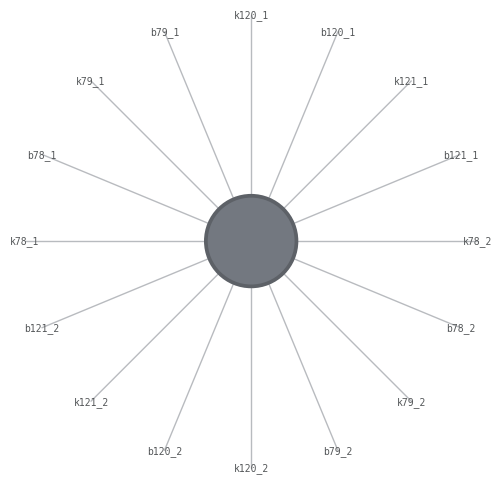

In [29]:
out.draw()

In [32]:
out.singular_values([
    'b79_1',
    'b78_1',
    'k79_1',
    'k78_1',
    'b79_2',
    'b78_2',
    'k79_2',
    'k78_2'
])

array([6.25000000e-02, 1.74760269e-17, 1.53548963e-17, 1.43942054e-17,
       1.35897981e-17, 1.22952790e-17, 1.15730191e-17, 1.15651008e-17,
       1.11119032e-17, 9.08989509e-18, 8.93113004e-18, 8.85436940e-18,
       8.73027880e-18, 7.94917436e-18, 7.71993775e-18, 7.53959895e-18,
       7.36481980e-18, 7.22003925e-18, 6.11636842e-18, 5.93041089e-18,
       5.56923104e-18, 5.37580775e-18, 4.94320512e-18, 4.79259690e-18,
       4.24608984e-18, 4.01538246e-18, 3.89742745e-18, 3.60886474e-18,
       3.56659506e-18, 3.47282588e-18, 3.41704723e-18, 2.82149673e-18,
       2.69253338e-18, 2.13240055e-18, 2.02202546e-18, 1.86408624e-18,
       1.74541907e-18, 1.41981210e-18, 1.32142586e-18, 9.79093725e-19,
       9.48605184e-19, 5.97597122e-19, 4.75778961e-19, 3.50321943e-19,
       5.59593891e-31, 3.68832833e-31, 2.15972533e-31, 1.92812443e-31,
       1.37710363e-31, 8.57969544e-32, 7.79332261e-32, 6.87844637e-32,
       5.96463896e-32, 5.54188065e-32, 5.03121860e-32, 4.68533678e-32,
      

So the left and right ''environment matrices'' decouple.

In [66]:
split_out = out.split(
    left_inds=[
        'b79_1',
        'b78_1',
        'k79_1',
        'k78_1',
        'b79_2',
        'b78_2',
        'k79_2',
        'k78_2'
    ],
    absorb=None,
    bond_ind='s'
)

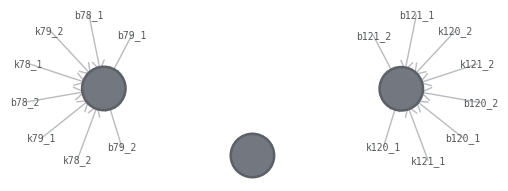

In [67]:
split_out.draw()

In [68]:
split_out.tensors[1]

Tensor(shape=(1,), inds=('s',), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

The decoupled diagram means that the left and right matrices effectively split.

In [69]:
left_out = split_out.tensors[0].isel({'s': 0})
right_out = split_out.tensors[2].isel({'s': 0})

Split again, see how they are coupled on either side.

In [70]:
left_out.singular_values(
    left_inds=[
        'b79_1',
        'b78_1',
        'k79_2',
        'k78_2'
    ]
)

array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25])

In [71]:
right_out

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k120_1', 'b120_1', 'k121_1', 'b121_1', 'k120_2', 'b120_2', 'k121_2', 'b121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [72]:
right_out.singular_values(
    left_inds=[
        'b120_1',
        'b121_1',
        'k120_2',
        'k121_2'
    ]
)

array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25])

So each environment matrix is strongly entangled. Hm..

In [73]:
right_out

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k120_1', 'b120_1', 'k121_1', 'b121_1', 'k120_2', 'b120_2', 'k121_2', 'b121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [105]:
first_unitary = unitary_group.rvs(4)

In [106]:
first_unitary = np.reshape(first_unitary, (2,2,2,2))

In [107]:
first_unitary

array([[[[-0.0826267 -0.06710422j,  0.3301998 -0.0651647j ],
         [-0.59256425+0.41465148j,  0.26360314+0.53182389j]],

        [[ 0.63271937+0.28839659j,  0.2402964 +0.19155517j],
         [ 0.4432754 +0.14068444j, -0.09960495+0.44255115j]]],


       [[[ 0.33741986+0.19221276j, -0.3162074 +0.54756996j],
         [-0.31088065-0.08667286j,  0.54852031-0.21059111j]],

        [[ 0.16764359+0.57119277j,  0.43729039-0.4486012j ],
         [-0.23709382-0.3166609j ,  0.09905927-0.29473408j]]]])

In [108]:
initial_left_boundary_op = qtn.tensor_core.Tensor(
    first_unitary,
    inds=['k120_1', 'k121_1', 'b120_2', 'b121_2']
)

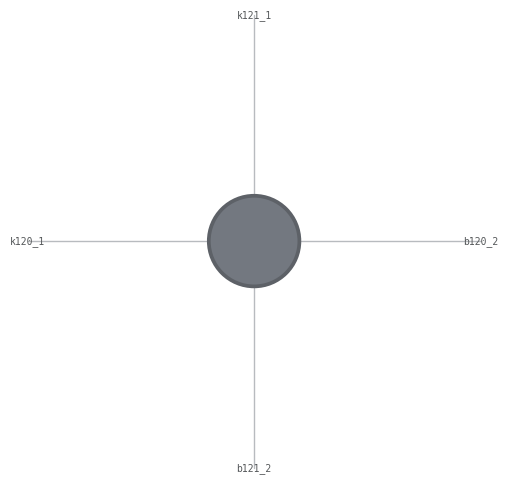

In [109]:
initial_left_boundary_op.draw()

In [110]:
partial_right_out = (initial_left_boundary_op & right_out) ^ ...

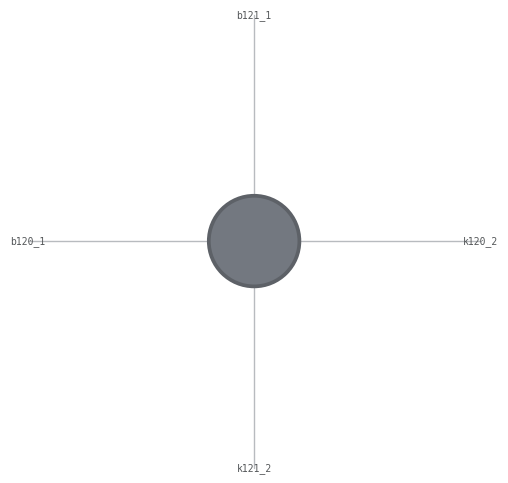

In [111]:
partial_right_out.draw()

In [112]:
svd = partial_right_out.split(
    left_inds=[
        'k120_2',
        'k121_2',
    ],
    absorb=None,
    bond_ind='s'
)

In [113]:
svd

TensorNetwork(tensors=3, indices=5)

In [114]:
svd.tensors[1].data

array([0.32910303, 0.26490789, 0.19927021, 0.17834346])

In [127]:
np.sum(svd.tensors[1].data)

0.9716245890087456

In [115]:
svd.tensors[0]

Tensor(shape=(2, 2, 4), inds=('k120_2', 'k121_2', 's'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']), left_inds=('k120_2', 'k121_2'))

In [116]:
svd.tensors[2]

Tensor(shape=(4, 2, 2), inds=('s', 'b120_1', 'b121_1'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']), left_inds=('b120_1', 'b121_1'))

In [123]:
unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...

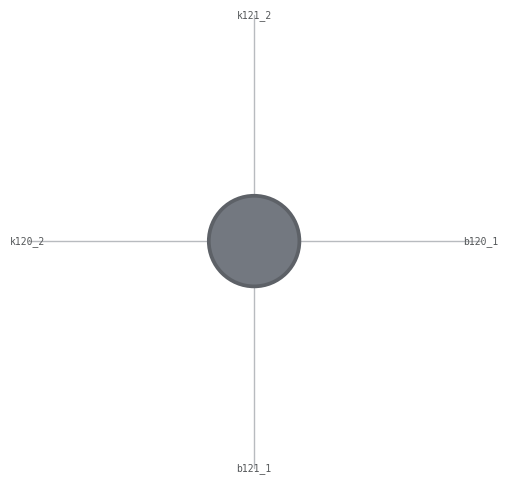

In [124]:
unitary.draw()

In [125]:
unitary = (
    unitary
    .reindex({
        'k121_2': 'b121_1',
        'k120_2': 'b120_1',
        'b121_1': 'k121_2',
        'b120_1': 'k120_2'
    })
    .conj()
)

In [126]:
unitary

Tensor(shape=(2, 2, 2, 2), inds=('b120_1', 'b121_1', 'k120_2', 'k121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [81]:
partial_right_out

Tensor(shape=(2, 2, 2, 2), inds=('b120_1', 'b121_1', 'k120_2', 'k121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [128]:
def svd_update(right_environment_matrix, left_boundary_guess):
    """
    Warning, lots of hard coding ahead!
    """
    partial_right_out = (left_boundary_guess & right_environment_matrix) ^ ...

    svd = partial_right_out.split(
        left_inds=[
            'k120_2',
            'k121_2',
        ],
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()

    
    partial_right_out = (first_unitary & right_environment_matrix) ^ ...

    svd = partial_right_out.split(
        left_inds=[
            'k120_1',
            'k121_1',
        ],
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

In [132]:
pair = svd_update(right_out, initial_left_boundary_op)

In [133]:
pair[1]

[0.9716245890087456, 0.9899229001826397]

In [134]:
pair[0][0]

Tensor(shape=(2, 2, 2, 2), inds=('k120_2', 'k121_2', 'b120_1', 'b121_1'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [136]:
pair[0][1]

Tensor(shape=(2, 2, 2, 2), inds=('k120_1', 'k121_1', 'b120_2', 'b121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [139]:
left_boundary_op = initial_left_boundary_op
scores = list()

for _ in range(20):
    quad = svd_update(right_out, left_boundary_op)
    scores.append(quad[1])
    left_boundary_op = quad[0][1]

In [140]:
scores

[[0.9716245890087456, 0.9899229001826397],
 [0.9956507721762267, 0.997961755749667],
 [0.9990074565252514, 0.9995075884179172],
 [0.9997534452985034, 0.9998759767447272],
 [0.9999374681696327, 0.9999684348832699],
 [0.99998405699459, 0.9999919450554697],
 [0.999995929756655, 0.9999979431090222],
 [0.9999989605134191, 0.9999994746666787],
 [0.9999997345056524, 0.9999998658230954],
 [0.9999999321888123, 0.9999999657291019],
 [0.9999999826799209, 0.999999991246647],
 [0.999999995576163, 0.9999999977642473],
 [0.9999999988700783, 0.999999999428951],
 [0.9999999997113985, 0.999999999854144],
 [0.9999999999262869, 0.9999999999627458],
 [0.9999999999811724, 0.9999999999904846],
 [0.999999999995191, 0.9999999999975693],
 [0.9999999999987715, 0.9999999999993787],
 [0.9999999999996857, 0.9999999999998416],
 [0.9999999999999195, 0.9999999999999589]]

In [142]:
scores = np.array(scores).flatten()

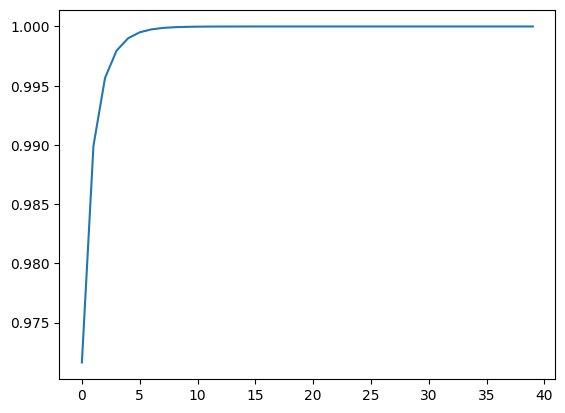

In [143]:
plt.plot(scores)

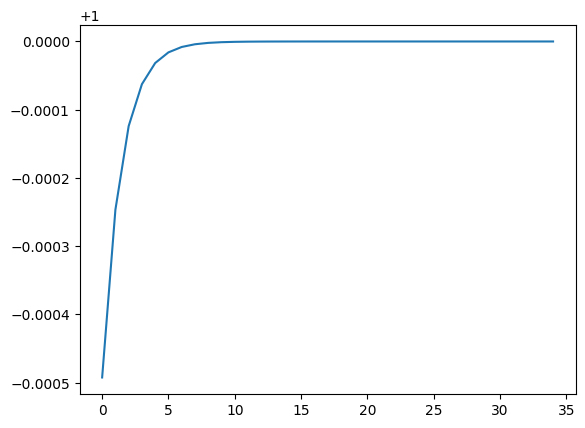

In [144]:
plt.plot(scores[5:])

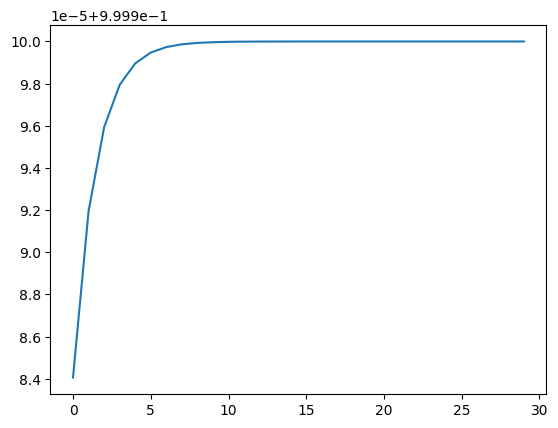

In [145]:
plt.plot(scores[10:])

Looks strictly increasing, this is good.

## Function definitions

In [151]:
def svd_update(environment_matrix, first_boundary_guess,
               first_left_inds, second_left_inds):
    """
    Should comment this.
    """
    first_env_matrix = (first_boundary_guess & environment_matrix) ^ ...

    svd = first_env_matrix.split(
        left_inds=first_left_inds,
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()

    
    second_env_matrix = (first_unitary & environment_matrix) ^ ...

    svd = second_env_matrix.split(
        left_inds=second_left_inds,
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

Need to continue this:
1. treatment of inds is problematic.

In [150]:
def iterated_svd_updates(environment_matrix, first_left_inds,
                         second_left_inds, num_iters):
    scores = list()

    # Hard code warning!
    rand_unitary = unitary_group.rvs(4)
    rand_unitary = np.reshape(rand_unitary, (2,2,2,2))

    boundary_guess = qtn.tensor_core.Tensor(
        rand_unitary,
        inds=['k120_1', 'k121_1', 'b120_2', 'b121_2']
    )

    for _ in range(num_iters):
        current_out = svd_update(
            environment_matrix,
            boundary_guess,
            first_left_inds,
            second_left_inds
        )
        scores.extend(quad[1])
        boundary_guess = quad[0][1]

    return (quad[0], scores)

Need to continue this:
1. treatment of inds is problematic.

In [154]:
def find_boundary_operators(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites):

    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    rho = psi.partial_trace_to_mpo(
        all_sites,
        rescale_sites=False
    )
    
    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in symmetry_sites
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in symmetry_sites
    ]

    two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )
    two_sided_environment_matrix.contract(inplace=False)

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_indices = [
        f'{bk}{i}_{j}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
        for j in [1, 2]
    ]

    split_two_sided_environment_matrix = two_sided_environment_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    two_sided_sing_vals = (
        split_two_sided_environment_matrix
        .tensors[1]
        .data
    )

    left_env_matrix = split_out.tensors[0].isel({'s': 0})
    right_env_matrix = split_out.tensors[2].isel({'s': 0})

    # Keep going, now extract boundary operators from these two.